# Decision Tree Prediction

## Objective:
This exercise is designed to help students apply the Decision Tree Classifier to a diabetes prediction dataset. The goal is to predict whether a person has diabetes based on various health-related features.

---

## 1. Data Dictionary

**Dataset Link:** [Diabetes Dataset](https://drive.google.com/file/d/1RRKsGCrRS65vInUn6MQYJJzEck9uYeF3/view)

The dataset contains the following attributes:

| Feature Name                         | Description                                                                                   | Data Type |
|--------------------------------------|-----------------------------------------------------------------------------------------------|-----------|
| Number of times pregnant             | Number of times the individual has been pregnant.                                              | Integer   |
| Plasma glucose concentration         | Plasma glucose concentration 2 hours after an oral glucose intake.                            | Integer   |
| Diastolic blood pressure             | Diastolic blood pressure (measured in mmHg).                                                   | Integer   |
| Triceps skin fold thickness          | Triceps skin fold thickness, a measure of body fat.                                           | Integer   |
| 2-Hour serum insulin                 | Insulin levels 2 hours after glucose intake.                                                   | Integer   |
| Body mass index (BMI)                | Weight in kg divided by height squared (m²).                                                   | Float     |
| Diabetes pedigree function           | A function representing genetic factors related to diabetes.                                  | Float     |
| Age (years)                          | Age of the individual.                                                                         | Integer   |
| Outcome                              | Target variable indicating if the individual has diabetes (YES/NO).                            | Categorical |

---

## 2. Problem Statement
The task is to build a Decision Tree model to predict whether an individual has diabetes based on the features provided. The challenge is to create a classifier that can accurately predict the outcome.

---

## 3. Data Pre-Processing

### 3.1 Data Inspection and Summary Statistics
- **Load the Dataset:** Import the dataset and review its basic structure, including column names, data types, and a few initial records.
- **Generate Summary Statistics:** Calculate key statistics (mean, median, min, max, standard deviation, etc.) to understand the primary characteristics of each column.

### 3.2 Data Cleaning and Feature Engineering
- **Missing Values:** Check and handle missing values if present.
- **Encoding Categorical Variables:** Convert the "Outcome" variable to binary format (1 for YES, 0 for NO).

### 3.3 Outlier Treatment
- **Outlier Detection:** Identify outliers in features such as plasma glucose concentration and BMI using box plots or Z-scores and apply treatment if necessary.

---

## 4. Exploratory Data Analysis (EDA)

### 4.1 Summary Statistics
- Calculate mean, median, variance, and standard deviation for each numerical feature.

### 4.2 Univariate Analysis
- **Numerical Data:** Visualize distributions with histograms and box plots.
- **Categorical Data:** Use bar charts to observe the distribution of the outcome variable.

### 4.3 Bivariate Analysis
- Create scatter plots to observe relationships between numerical features.
- Use box plots to explore how numerical features differ based on the outcome variable.
- Generate a heatmap of the correlation matrix to identify potential relationships.

---

## 5. Model Building

### 5.1 Model Training
- Split the dataset into training and testing sets.
- Use a Logistic Regression to train the model on the training data.
- Predict the train model on test data
----

#### Imporing all the libraries

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 

#### Loading Dataset

In [2]:
df = pd.read_csv("Diabetes.csv")

## Data Pre-Processing

### 3.1 Data Inspection and Summary Statistics

In [3]:
df.head()

,Number of times pregnant,Plasma glucose concentration,Diastolic blood pressure,Triceps skin fold thickness,2-Hour serum insulin,Body mass index,Diabetes pedigree function,Age (years),Outcome
0,6,148,72,35,0,33.6,0.627,50,YES
1,1,85,66,29,0,26.6,0.351,31,NO
2,8,183,64,0,0,23.3,0.672,32,YES
3,1,89,66,23,94,28.1,0.167,21,NO
4,0,137,40,35,168,43.1,2.288,33,YES


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0    Number of times pregnant      768 non-null    int64  
 1    Plasma glucose concentration  768 non-null    int64  
 2    Diastolic blood pressure      768 non-null    int64  
 3    Triceps skin fold thickness   768 non-null    int64  
 4    2-Hour serum insulin          768 non-null    int64  
 5    Body mass index               768 non-null    float64
 6    Diabetes pedigree function    768 non-null    float64
 7    Age (years)                   768 non-null    int64  
 8   Outcome                        768 non-null    object 
dtypes: float64(2), int64(6), object(1)
memory usage: 54.1+ KB


In [5]:
df.shape

(768, 9)

In [6]:
df.size

6912

In [7]:
df.describe()

,Number of times pregnant,Plasma glucose concentration,Diastolic blood pressure,Triceps skin fold thickness,2-Hour serum insulin,Body mass index,Diabetes pedigree function,Age (years)
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


In [8]:
# Renaming columns
df = df.rename(columns={
    ' Number of times pregnant': 'Pregnancies',
    ' Plasma glucose concentration': 'Glucose',
    ' Diastolic blood pressure': 'Blood_Pressure',
    ' Triceps skin fold thickness': 'Skin_Thickness',
    ' 2-Hour serum insulin': 'Insulin',
    ' Body mass index': 'BMI',
    ' Diabetes pedigree function': 'Diabetes_Pedigree_Function',
    ' Age (years)': 'Age'
})

### 3.2 Data Cleaning and Feature Engineering

In [9]:
df.isnull().sum()

Pregnancies                   0
Glucose                       0
Blood_Pressure                0
Skin_Thickness                0
Insulin                       0
BMI                           0
Diabetes_Pedigree_Function    0
Age                           0
Outcome                       0
dtype: int64

#### There is no Missing Values in the Dataset 

In [10]:
print(df.duplicated().sum())

0


### Encoding Categorical Variables

In [11]:
# Encoding 'Outcome' column
df['Outcome'] = df['Outcome'].map({'YES': 1, 'NO': 0})

#### There are not Duplicated Values in Dataset

In [12]:
numerical_columns = df.select_dtypes(include=[np.number]).columns 

In [13]:
numerical_columns

Index(['Pregnancies', 'Glucose', 'Blood_Pressure', 'Skin_Thickness', 'Insulin',
       'BMI', 'Diabetes_Pedigree_Function', 'Age', 'Outcome'],
      dtype='object')

In [14]:
["Glucose","Skin_Thickness","Blood_Pressure","Skin_Thickness", "Insulin","BMI","Diabetes_Pedigree_Function"]

['Glucose',
 'Skin_Thickness',
 'Blood_Pressure',
 'Skin_Thickness',
 'Insulin',
 'BMI',
 'Diabetes_Pedigree_Function']

### 3.3 Outlier Treatment

<Axes: ylabel='Skin_Thickness'>

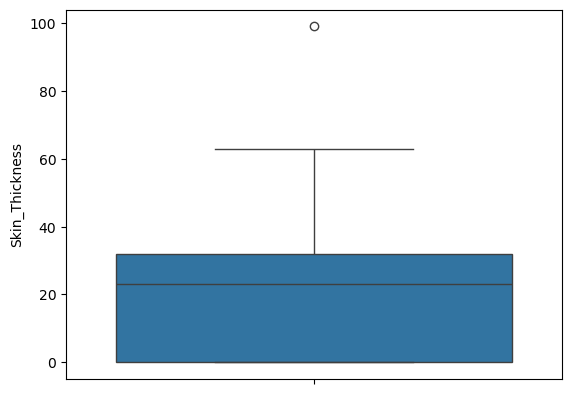

In [15]:
sns.boxplot(df['Skin_Thickness'])

In [16]:
df[df['Skin_Thickness'] ==0]

,Pregnancies,Glucose,Blood_Pressure,Skin_Thickness,Insulin,BMI,Diabetes_Pedigree_Function,Age,Outcome
2,8,183,64,0,0,23.3,0.672,32,1
5,5,116,74,0,0,25.6,0.201,30,0
7,10,115,0,0,0,35.3,0.134,29,0
9,8,125,96,0,0,0.0,0.232,54,1
10,4,110,92,0,0,37.6,0.191,30,0
...,...,...,...,...,...,...,...,...,...
757,0,123,72,0,0,36.3,0.258,52,1
758,1,106,76,0,0,37.5,0.197,26,0
759,6,190,92,0,0,35.5,0.278,66,1
762,9,89,62,0,0,22.5,0.142,33,0


In [17]:
median_skin_thickness = df[df['Skin_Thickness']!=0]['Skin_Thickness'].median()
print(median_skin_thickness)
df['Skin_Thickness'] = df['Skin_Thickness'].replace(0,median_skin_thickness)

29.0


- **`0.0` as Invalid Data**: Zero values likely represent missing or erroneous data, not actual measurements.
- **Distortion of Analysis**: Zero values can skew statistical calculations, such as mean and standard deviation.
- **Using Median**: The median is less sensitive to outliers and better represents typical values.
- **Improved Model Accuracy**: Replacing outliers with the median ensures better data quality and improves model performance.

Processing column: Glucose


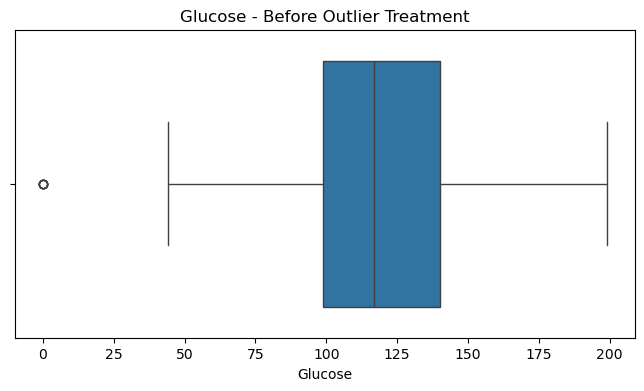

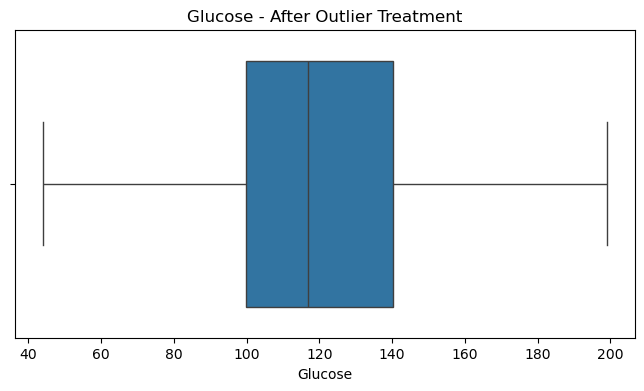

Processing column: Skin_Thickness


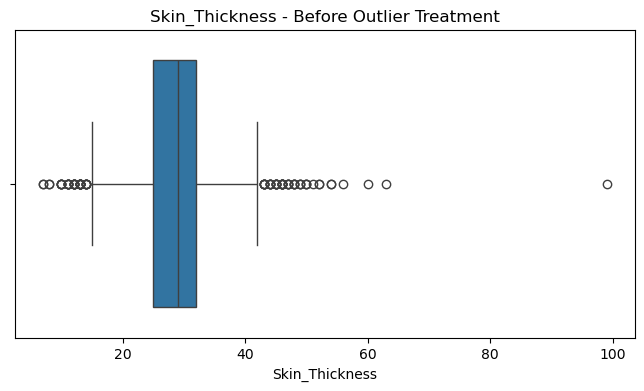

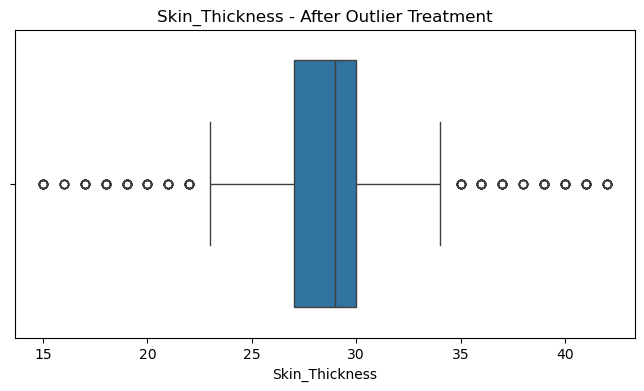

Processing column: Blood_Pressure


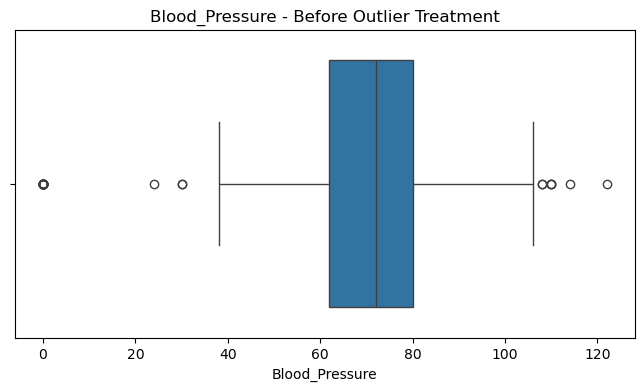

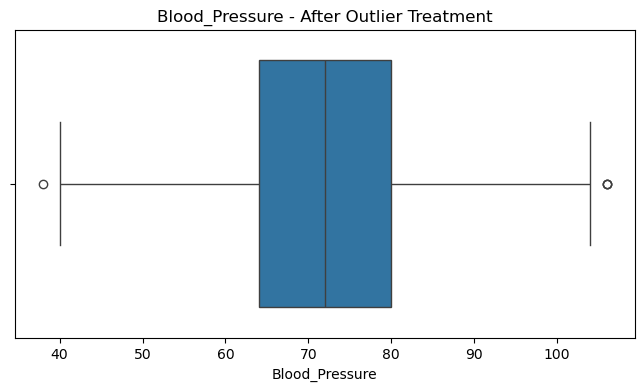

Processing column: Insulin


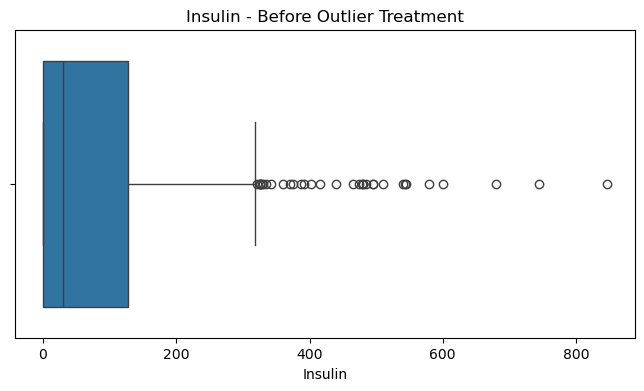

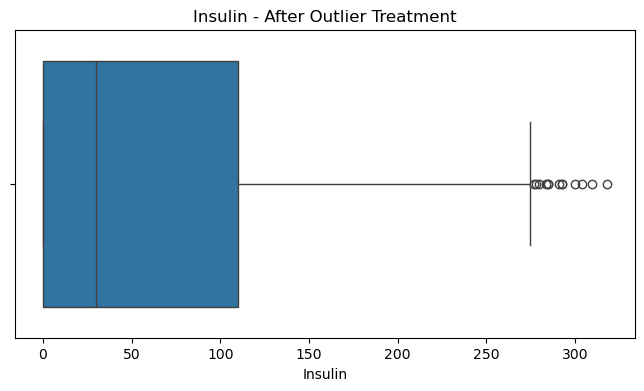

Processing column: BMI


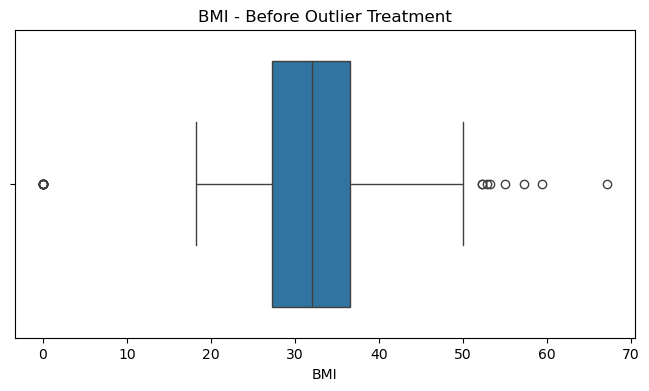

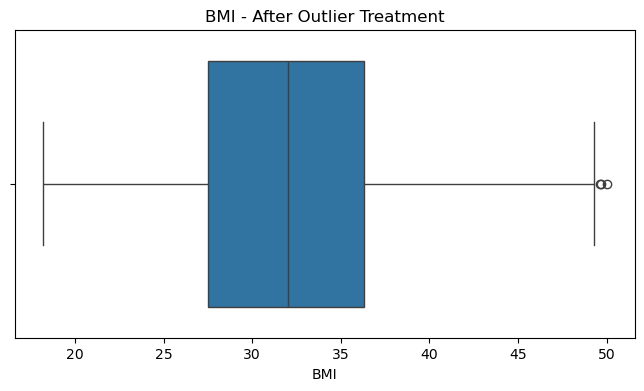

Processing column: Diabetes_Pedigree_Function


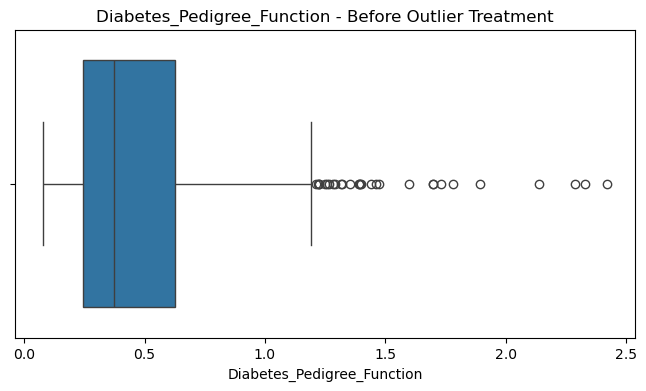

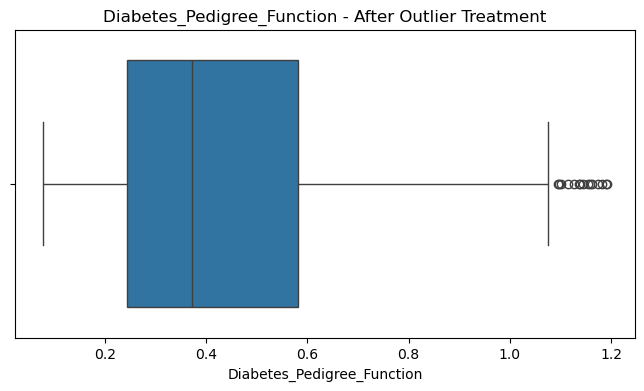

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Function for outlier detection and treatment
def outlier_treatment(df):
    # Specified columns for outlier treatment
    specified_columns = ["Glucose", "Skin_Thickness", "Blood_Pressure", "Insulin", "BMI", "Diabetes_Pedigree_Function"]
    
    for column in specified_columns:
        print(f"Processing column: {column}")
        
        # Box plot before treatment
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=df[column])
        plt.title(f"{column} - Before Outlier Treatment")
        plt.show()
        
        # Calculate IQR, lower and upper bounds
        Q1 = df[column].quantile(0.25)  
        Q3 = df[column].quantile(0.75)  
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Replace outliers with the median
        median_value = df[column].median()
        df[column] = df[column].apply(
            lambda x: median_value if x < lower_bound or x > upper_bound else x
        )
        
        # Box plot after treatment
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=df[column])
        plt.title(f"{column} - After Outlier Treatment")
        plt.show()
    
    return df

df_cleaned = outlier_treatment(df)


## 4. Exploratory Data Analysis (EDA)

### 4.1 Summary Statistics


In [19]:
df.describe()

,Pregnancies,Glucose,Blood_Pressure,Skin_Thickness,Insulin,BMI,Diabetes_Pedigree_Function,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.196615,28.759115,60.919271,32.198958,0.427667,33.240885,0.348958
std,3.369578,30.438286,11.146723,5.766472,77.635666,6.410558,0.245162,11.760232,0.476951
min,0.000000,44.000000,38.000000,15.000000,0.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,27.000000,0.000000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,29.750000,32.000000,0.371750,29.000000,0.000000
75%,6.000000,140.250000,80.000000,30.000000,110.000000,36.300000,0.582250,41.000000,1.000000
max,17.000000,199.000000,106.000000,42.000000,318.000000,50.000000,1.191000,81.000000,1.000000


### 4.2 Univariate Analysis


In [20]:
df

,Pregnancies,Glucose,Blood_Pressure,Skin_Thickness,Insulin,BMI,Diabetes_Pedigree_Function,Age,Outcome
0,6,148.0,72.0,35.0,0.0,33.6,0.6270,50,1
1,1,85.0,66.0,29.0,0.0,26.6,0.3510,31,0
2,8,183.0,64.0,29.0,0.0,23.3,0.6720,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.1670,21,0
4,0,137.0,40.0,35.0,168.0,43.1,0.3725,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,29.0,180.0,32.9,0.1710,63,0
764,2,122.0,70.0,27.0,0.0,36.8,0.3400,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.2450,30,0
766,1,126.0,60.0,29.0,0.0,30.1,0.3490,47,1


### Univariate Numerical Analysis

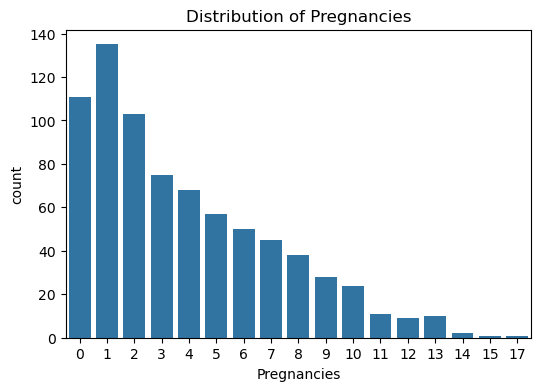

In [21]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Pregnancies')
plt.title("Distribution of Pregnancies")
plt.show()

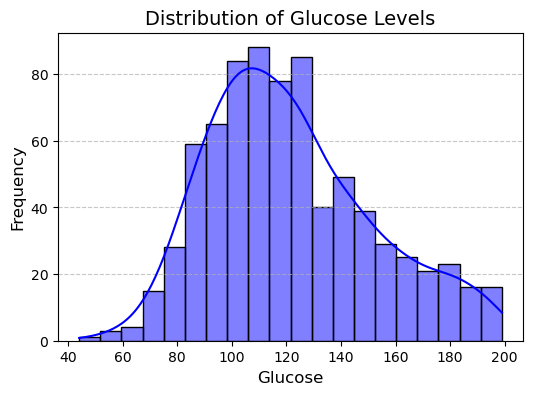

In [22]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='Glucose', bins=20, kde=True, color='blue')  
plt.title("Distribution of Glucose Levels", fontsize=14)
plt.xlabel("Glucose", fontsize=12)  
plt.ylabel("Frequency", fontsize=12)  
plt.grid(axis='y', linestyle='--', alpha=0.7)  
plt.show()


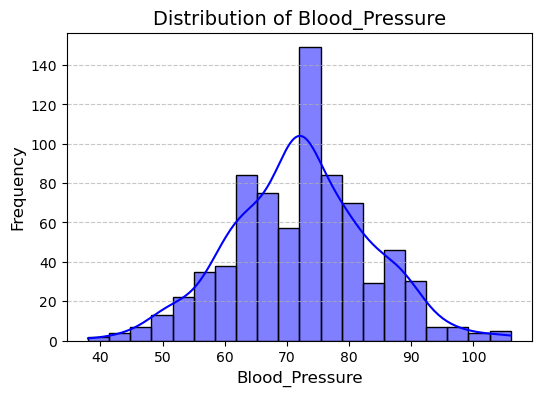

In [23]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='Blood_Pressure', bins=20, kde=True, color='blue')  
plt.title("Distribution of Blood_Pressure", fontsize=14)
plt.xlabel("Blood_Pressure", fontsize=12)  
plt.ylabel("Frequency", fontsize=12)  
plt.grid(axis='y', linestyle='--', alpha=0.7)  
plt.show()


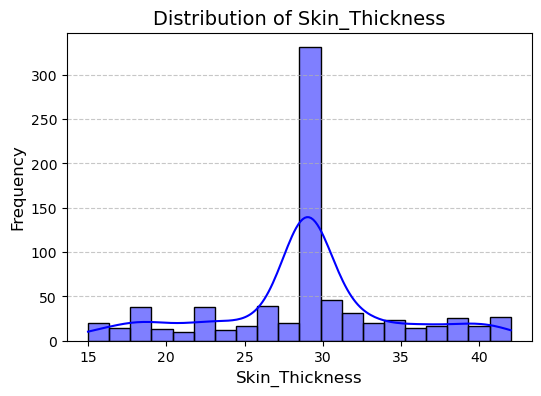

In [24]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='Skin_Thickness', bins=20, kde=True, color='blue')  
plt.title("Distribution of Skin_Thickness", fontsize=14)
plt.xlabel("Skin_Thickness", fontsize=12)  
plt.ylabel("Frequency", fontsize=12)  
plt.grid(axis='y', linestyle='--', alpha=0.7)  
plt.show()

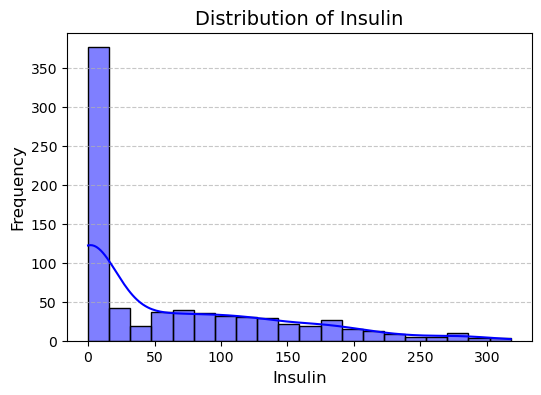

In [25]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='Insulin', bins=20, kde=True, color='blue')  
plt.title("Distribution of Insulin", fontsize=14)
plt.xlabel("Insulin", fontsize=12)  
plt.ylabel("Frequency", fontsize=12)  
plt.grid(axis='y', linestyle='--', alpha=0.7)  
plt.show()

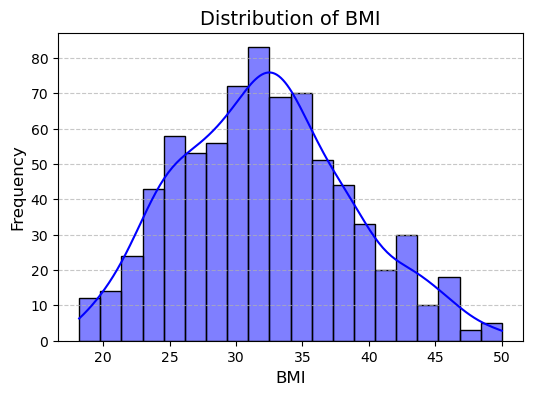

In [26]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='BMI', bins=20, kde=True, color='blue')  
plt.title("Distribution of BMI", fontsize=14)
plt.xlabel("BMI", fontsize=12)  
plt.ylabel("Frequency", fontsize=12)  
plt.grid(axis='y', linestyle='--', alpha=0.7)  
plt.show()

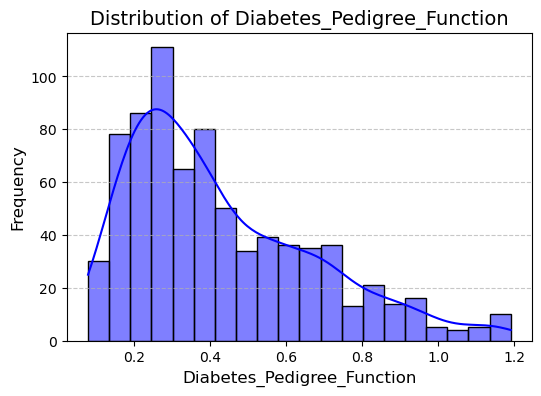

In [27]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='Diabetes_Pedigree_Function', bins=20, kde=True, color='blue')  
plt.title("Distribution of Diabetes_Pedigree_Function", fontsize=14)
plt.xlabel("Diabetes_Pedigree_Function", fontsize=12)  
plt.ylabel("Frequency", fontsize=12)  
plt.grid(axis='y', linestyle='--', alpha=0.7)  
plt.show()

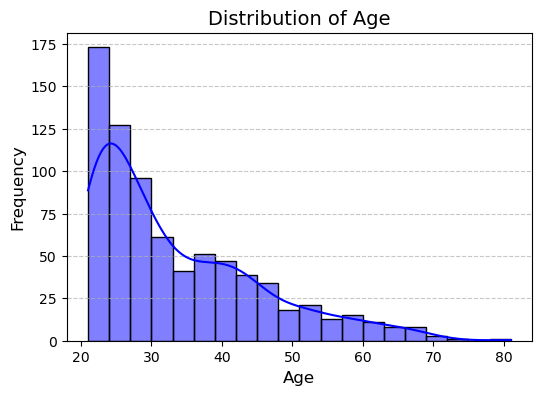

In [28]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='Age', bins=20, kde=True, color='blue')  
plt.title("Distribution of Age", fontsize=14)
plt.xlabel("Age", fontsize=12)  
plt.ylabel("Frequency", fontsize=12)  
plt.grid(axis='y', linestyle='--', alpha=0.7)  
plt.show()

### 4.3 Bivariate Analysis

In [29]:
df.head()

,Pregnancies,Glucose,Blood_Pressure,Skin_Thickness,Insulin,BMI,Diabetes_Pedigree_Function,Age,Outcome
0,6,148.0,72.0,35.0,0.0,33.6,0.6270,50,1
1,1,85.0,66.0,29.0,0.0,26.6,0.3510,31,0
2,8,183.0,64.0,29.0,0.0,23.3,0.6720,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.1670,21,0
4,0,137.0,40.0,35.0,168.0,43.1,0.3725,33,1


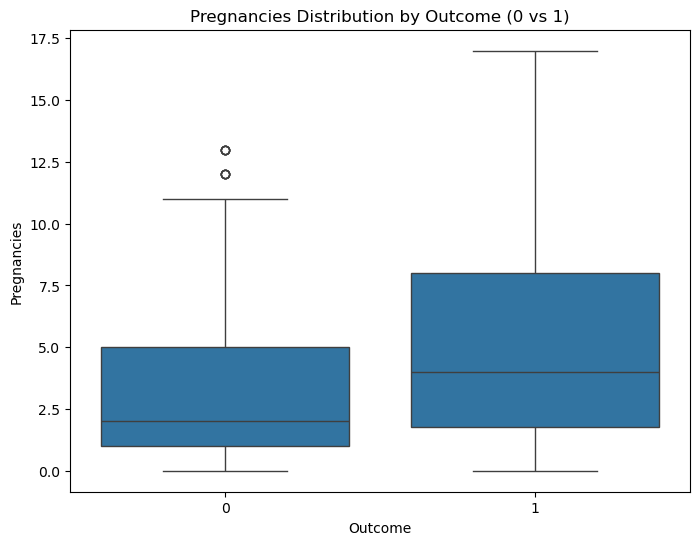

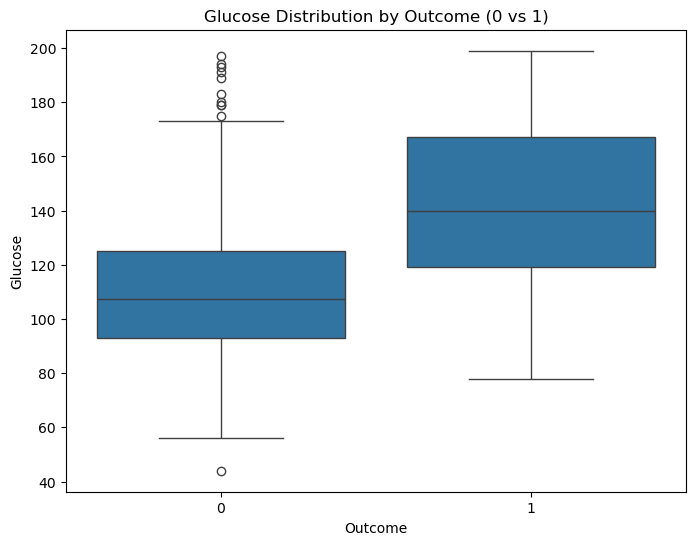

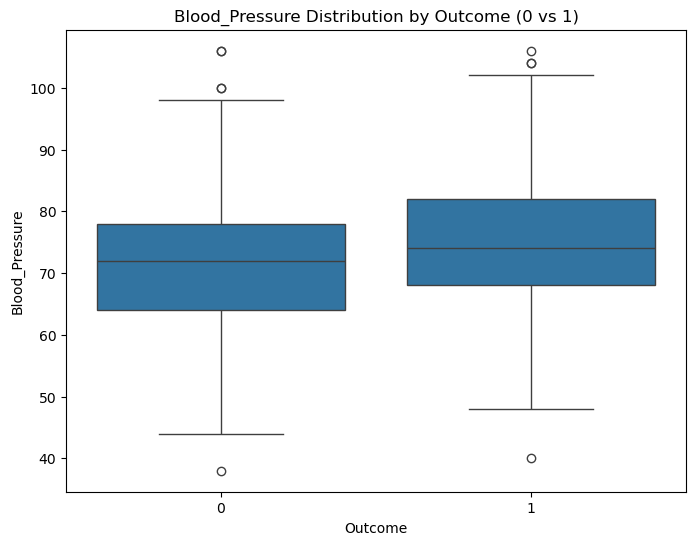

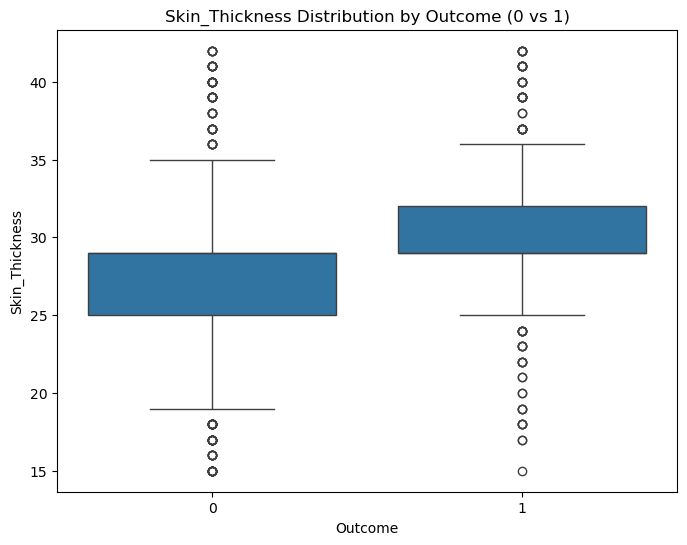

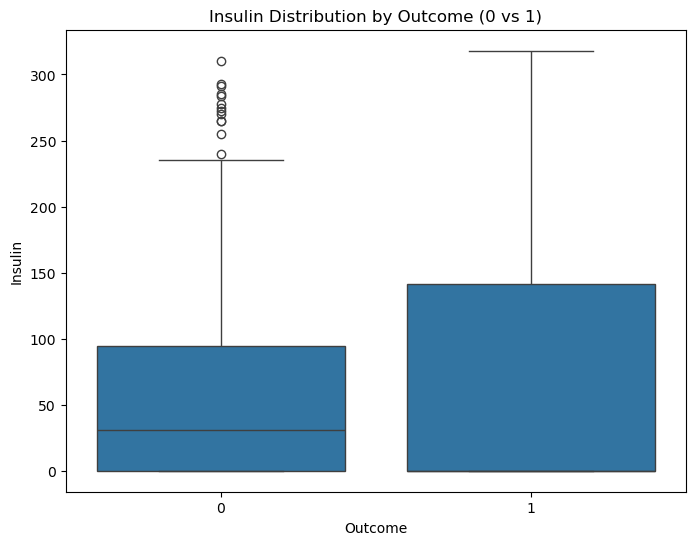

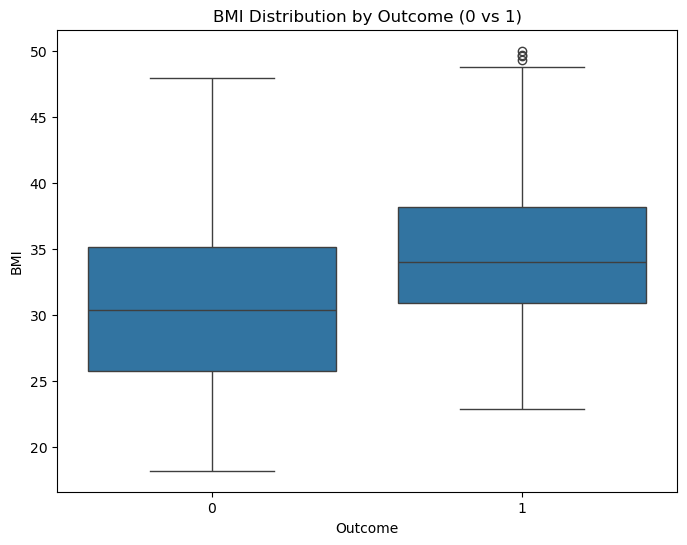

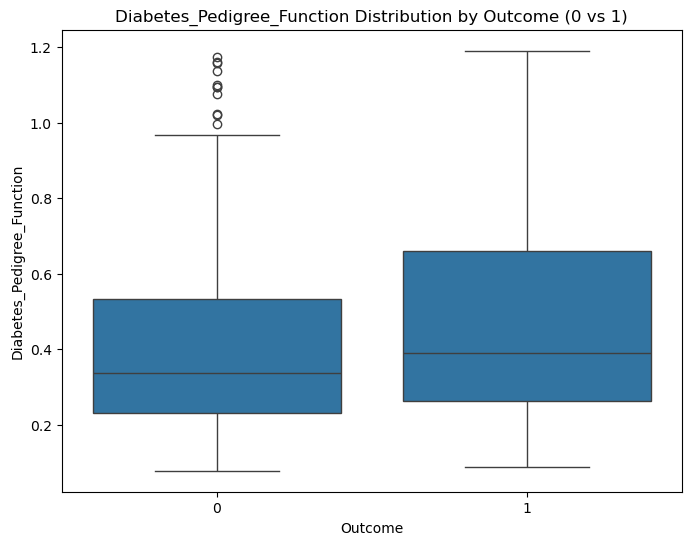

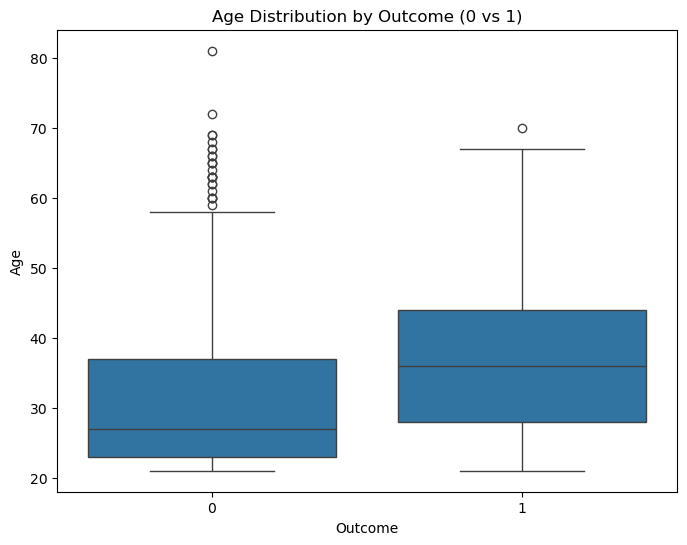

In [30]:
# Box plots for each numerical column by Outcome
numerical_columns = ['Pregnancies', 'Glucose', 'Blood_Pressure', 'Skin_Thickness', 'Insulin', 'BMI', 'Diabetes_Pedigree_Function', 'Age']

for col in numerical_columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='Outcome', y=col, data=df)
    plt.title(f"{col} Distribution by Outcome (0 vs 1)")
    plt.show()


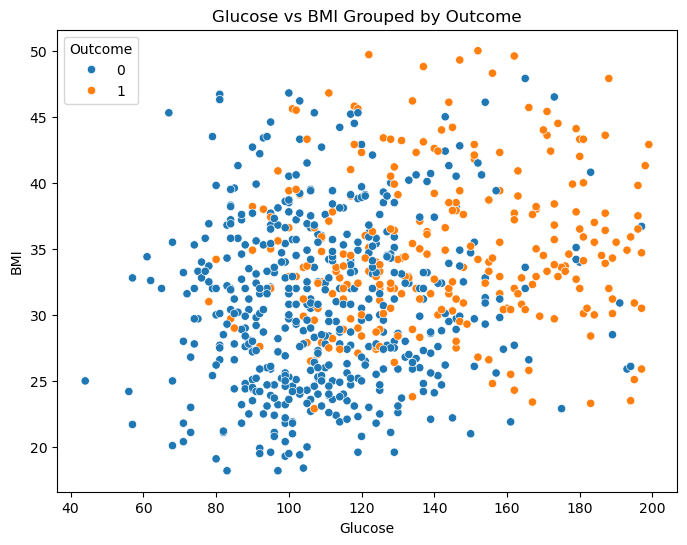

In [31]:
# Scatter plot for Glucose vs BMI grouped by Outcome
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Glucose', y='BMI', hue='Outcome', data=df)
plt.title("Glucose vs BMI Grouped by Outcome")
plt.show()


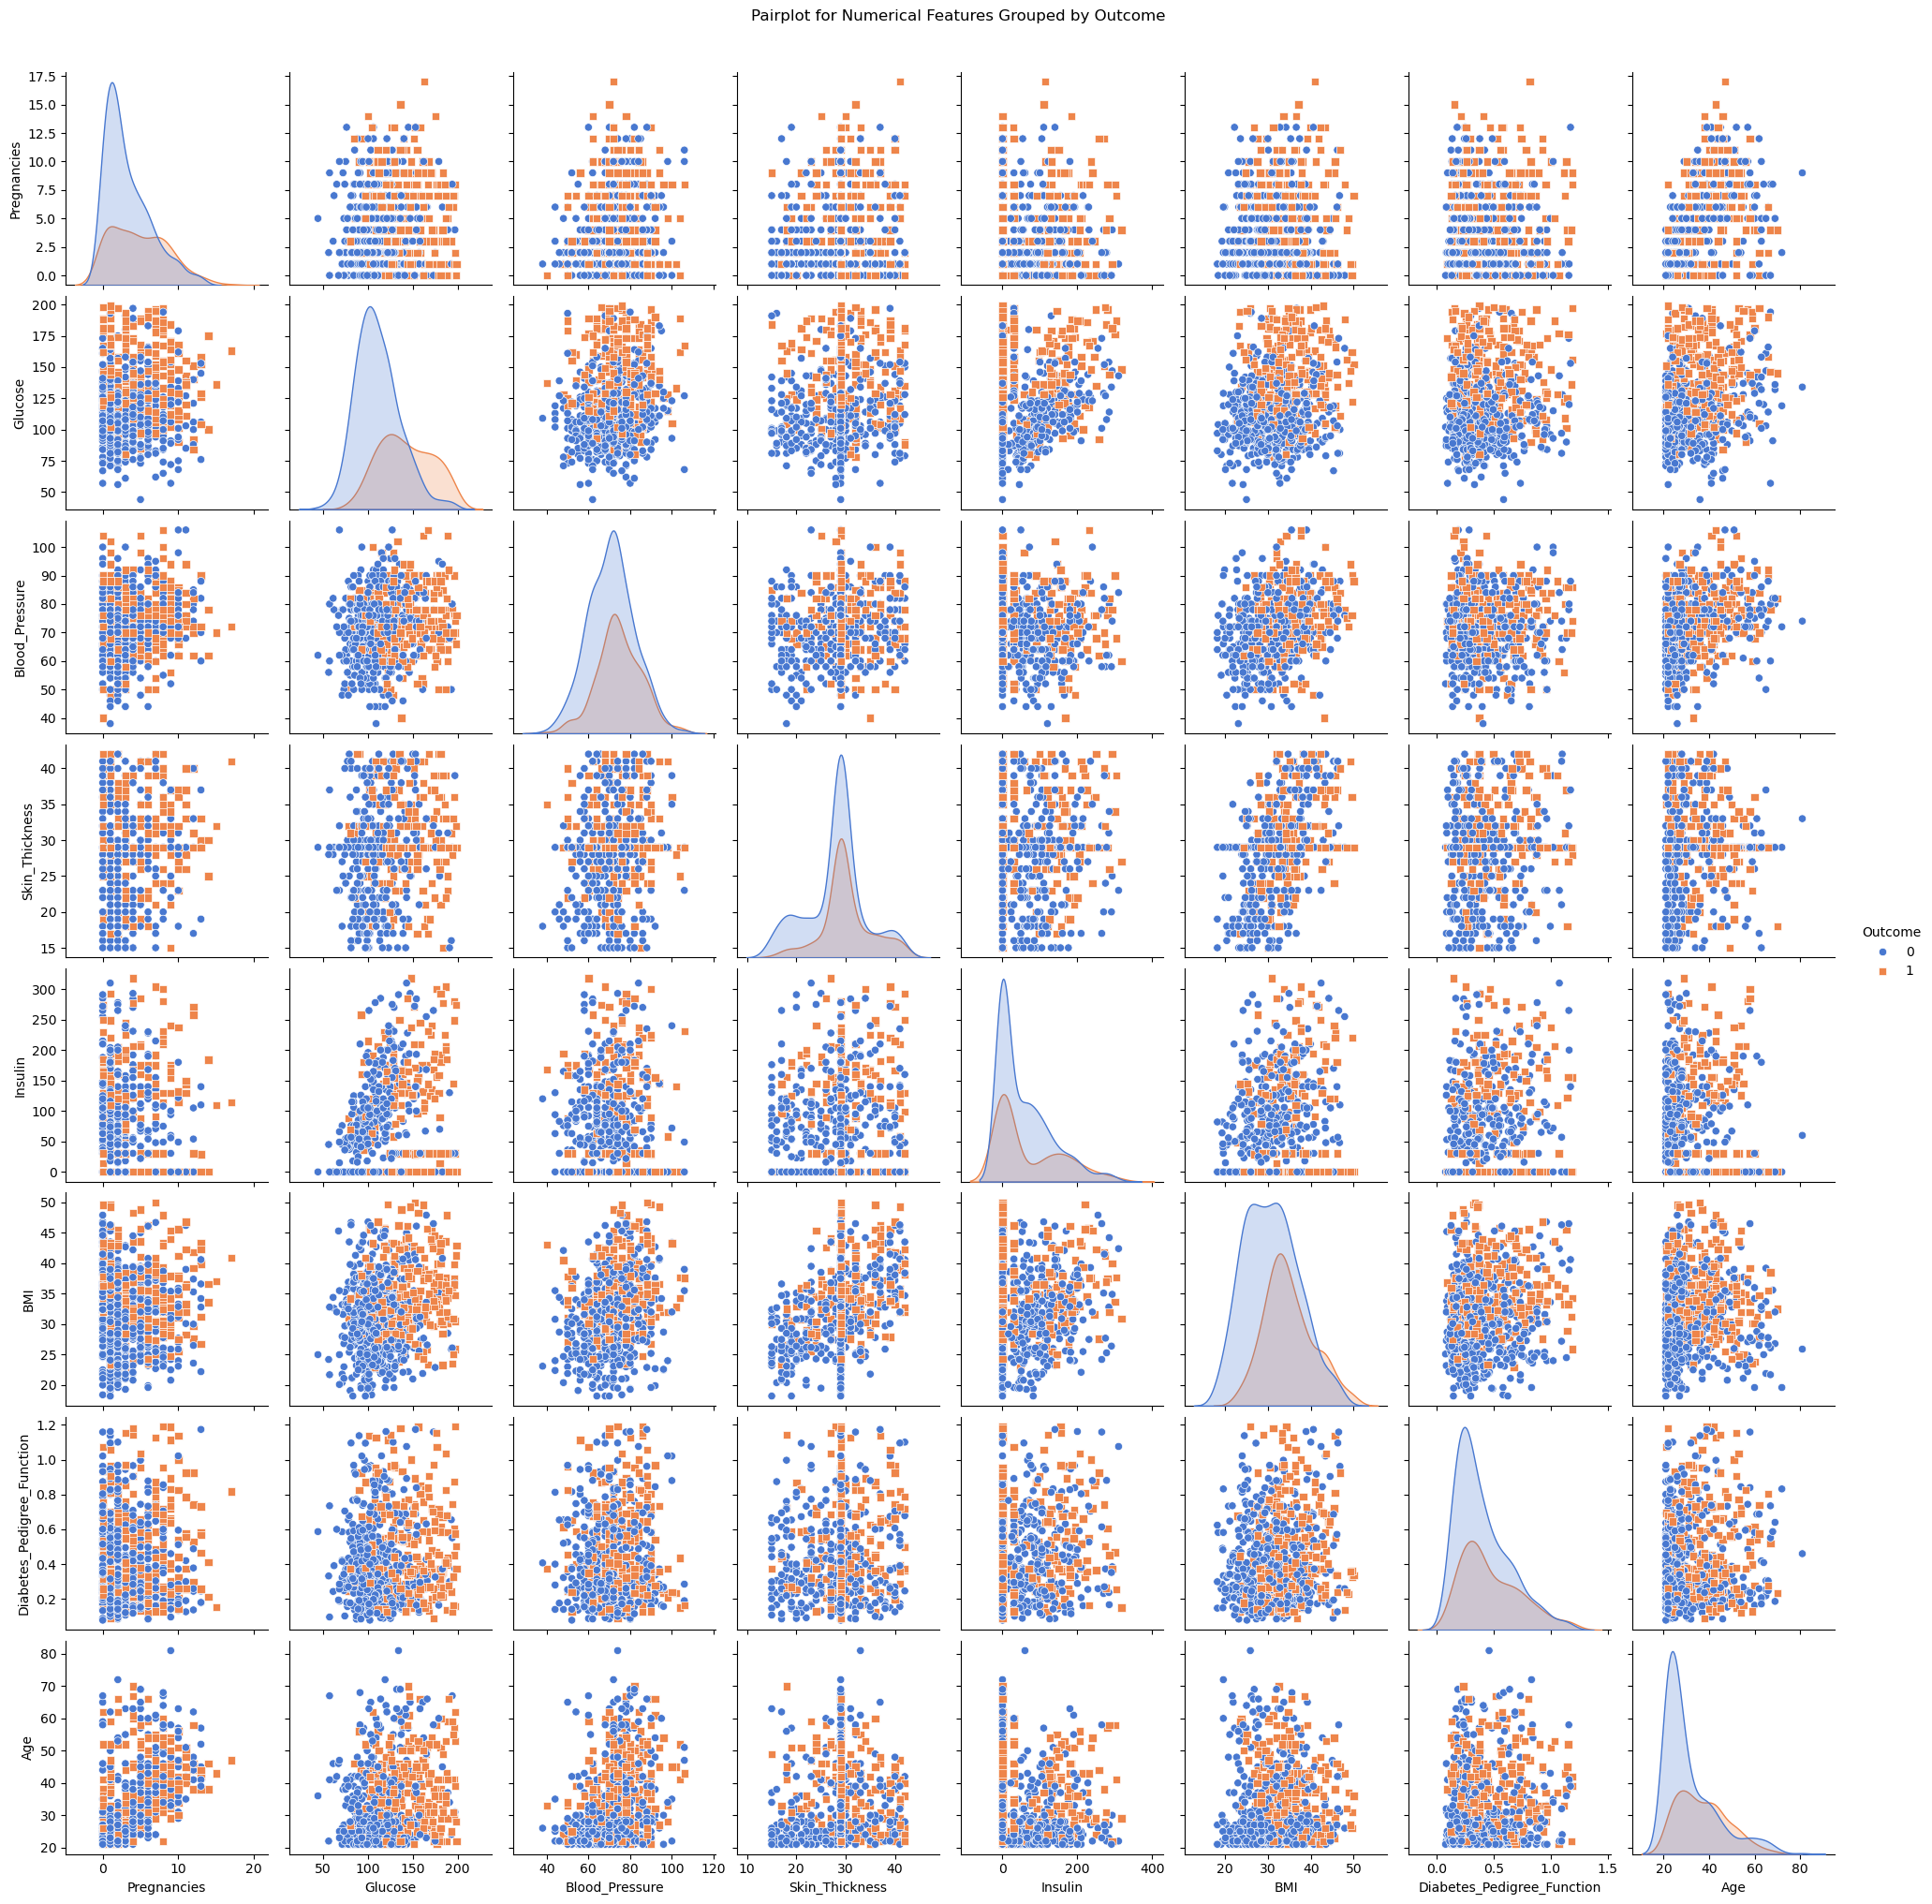

In [32]:
# Pairplot to show relationships between features, grouped by Outcome
sns.pairplot(df, vars=numerical_columns, hue="Outcome", markers=["o", "s"], palette="muted")
plt.suptitle("Pairplot for Numerical Features Grouped by Outcome", y=1.02)
plt.show()

In [33]:
df.groupby(["Outcome"])[['Glucose','Blood_Pressure',"Skin_Thickness"]].mean().reset_index()

,Outcome,Glucose,Blood_Pressure,Skin_Thickness
0,0,110.682000,70.852000,28.006000
1,1,142.130597,74.705224,30.164179


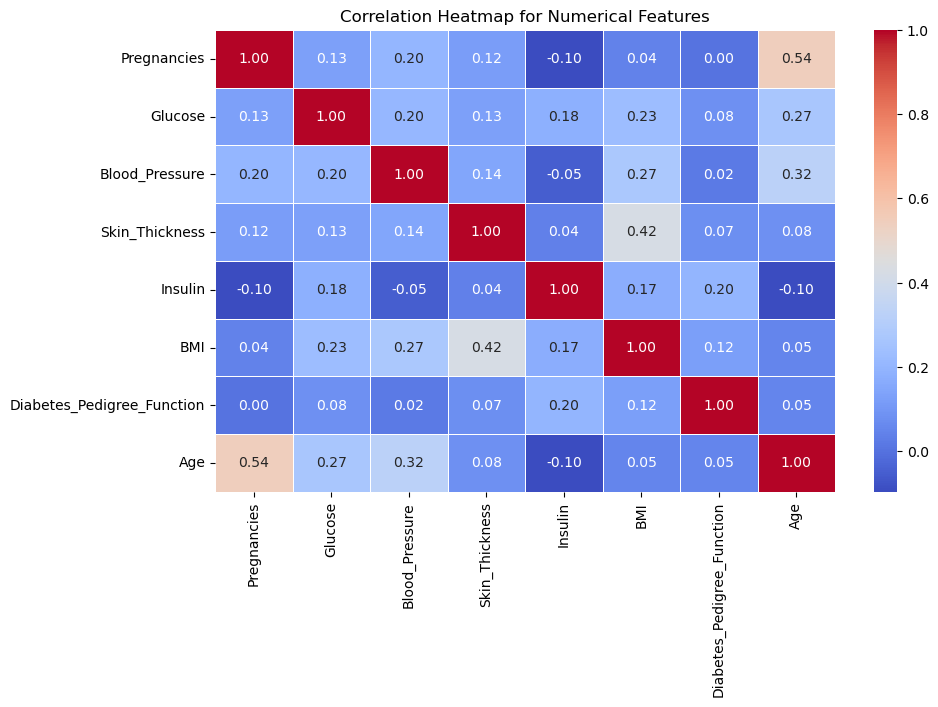

In [34]:
# Correlation matrix to show relationships between numerical features
corr = df[numerical_columns].corr()

# Plotting the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap for Numerical Features")
plt.show()


## 5. Model Building



In [35]:
X = df.drop('Outcome',axis = 1)
y = df[['Outcome']]

### Train Test Split

In [36]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=0)

In [37]:
X_train.head()

,Pregnancies,Glucose,Blood_Pressure,Skin_Thickness,Insulin,BMI,Diabetes_Pedigree_Function,Age
762,9,89.0,62.0,29.0,0.0,22.5,0.142,33
127,1,118.0,58.0,36.0,94.0,33.3,0.261,23
564,0,91.0,80.0,29.0,0.0,32.4,0.601,27
375,12,140.0,82.0,29.0,30.5,39.2,0.528,58
663,9,145.0,80.0,29.0,130.0,37.9,0.637,40


In [38]:
X_test.head()

,Pregnancies,Glucose,Blood_Pressure,Skin_Thickness,Insulin,BMI,Diabetes_Pedigree_Function,Age
661,1,199.0,76.0,29.0,0.0,42.9,0.3725,22
122,2,107.0,74.0,30.0,100.0,33.6,0.4040,23
113,4,76.0,62.0,29.0,0.0,34.0,0.3910,25
14,5,166.0,72.0,19.0,175.0,25.8,0.5870,51
529,0,111.0,65.0,29.0,0.0,24.6,0.6600,31


In [39]:
y_train.head()

,Outcome
762,0
127,0
564,0
375,1
663,1


In [40]:
y_test.head()

,Outcome
661,1
122,0
113,0
14,1
529,0


### 5.1 Model Training

In [41]:
X_train

,Pregnancies,Glucose,Blood_Pressure,Skin_Thickness,Insulin,BMI,Diabetes_Pedigree_Function,Age
762,9,89.0,62.0,29.0,0.0,22.5,0.142,33
127,1,118.0,58.0,36.0,94.0,33.3,0.261,23
564,0,91.0,80.0,29.0,0.0,32.4,0.601,27
375,12,140.0,82.0,29.0,30.5,39.2,0.528,58
663,9,145.0,80.0,29.0,130.0,37.9,0.637,40
...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,29.0,180.0,32.9,0.171,63
192,7,159.0,66.0,29.0,0.0,30.4,0.383,36
629,4,94.0,65.0,22.0,0.0,24.7,0.148,21
559,11,85.0,74.0,29.0,0.0,30.1,0.300,35


In [42]:
from sklearn.linear_model import LogisticRegression

In [43]:
model = LogisticRegression(random_state=42)


# Train the model
model.fit(X_train, y_train)

C:\Users\abhis\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\abhis\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [44]:
# Make predictions on the test data
y_pred = model.predict(X_test)
print(y_pred)

[1 0 0 1 0 0 1 1 0 0 1 1 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0
 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 1 1 1 0 0 0 0 0 0 1
 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 1 0 0 0 1 0
 0 1 0 1 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 1 0 0 0 0 1 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1
 0 0 0 0 0 0 0]
